In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re, string, gc, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import *

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

!pip install sentence-transformers prophet pmdarima optuna --quiet

from sentence_transformers import SentenceTransformer
from prophet import Prophet
from pmdarima import auto_arima
import optuna

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 40.4 MB/s eta 0:00:00


In [3]:
# ============================================================
# 1. LOAD DATASET
# ============================================================

products  = pd.read_csv("products.csv",  parse_dates=["launch_date"])
sales     = pd.read_csv("sales.csv",     parse_dates=["date"])
marketing = pd.read_csv("marketing.csv", parse_dates=["start_date","end_date"])
reviews   = pd.read_csv("reviews.csv",   parse_dates=["date"])

In [4]:
# ============================================================
# 2. QUICK EDA: STRUKTUR & QUALITY CHECK
# ============================================================


print("\n=== BASIC INFO: PRODUCTS ===")
print(products.head())
print(products.info())
print(products.describe(include="all"))

print("\n=== BASIC INFO: SALES ===")
print(sales.head())
print(sales.info())
print(sales.describe())

print("\n=== BASIC INFO: MARKETING ===")
print(marketing.head())
print(marketing.info())
print(marketing.describe(include="all"))

print("\n=== BASIC INFO: REVIEWS ===")
print(reviews.head())
print(reviews.info())
print(reviews.describe(include="all"))

# Missing value summary
def missing_summary(df, name):
    print(f"\n=== MISSING VALUE SUMMARY: {name} ===")
    print(df.isna().sum().sort_values(ascending=False))

missing_summary(products, "products")
missing_summary(sales, "sales")
missing_summary(marketing, "marketing")
missing_summary(reviews, "reviews")

# Unique counts for categorical columns
def cat_summary(df, cat_cols, name):
    print(f"\n=== CATEGORICAL SUMMARY: {name} ===")
    for c in cat_cols:
        print(f"\nColumn: {c}")
        print(df[c].value_counts().head(20))

cat_summary(products, ["brand", "type"], "products")
cat_summary(sales, ["product_id", "region", "channel"], "sales")
cat_summary(marketing, ["product_id", "channel"], "marketing")
cat_summary(reviews, ["product_id", "sentiment", "platform"], "reviews")


=== BASIC INFO: PRODUCTS ===
  product_id                           product_name     brand         type  \
0      PC001   Sunsilk Smooth & Shine Shampoo 340ml   Sunsilk      Shampoo   
1      PC002  Sunsilk Black Shine Conditioner 340ml   Sunsilk  Conditioner   
2      PC003       Lifebuoy Total10 Body Wash 400ml  Lifebuoy    Body Wash   
3      PC004      Lifebuoy Mild Care Handwash 200ml  Lifebuoy     Handwash   
4      PC005        Dove Deep Moisture Lotion 200ml      Dove       Lotion   

   size_ml  base_price launch_date  
0      340       32000  2020-02-15  
1      340       33000  2020-06-10  
2      400       28000  2020-03-20  
3      200       25000  2021-05-01  
4      200       35000  2021-11-12  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    15 non-null     object        
 1   product_name  15 non-n

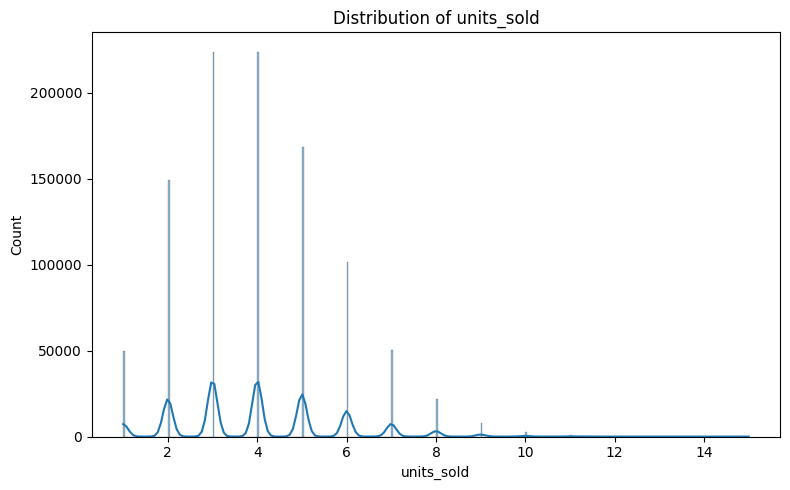

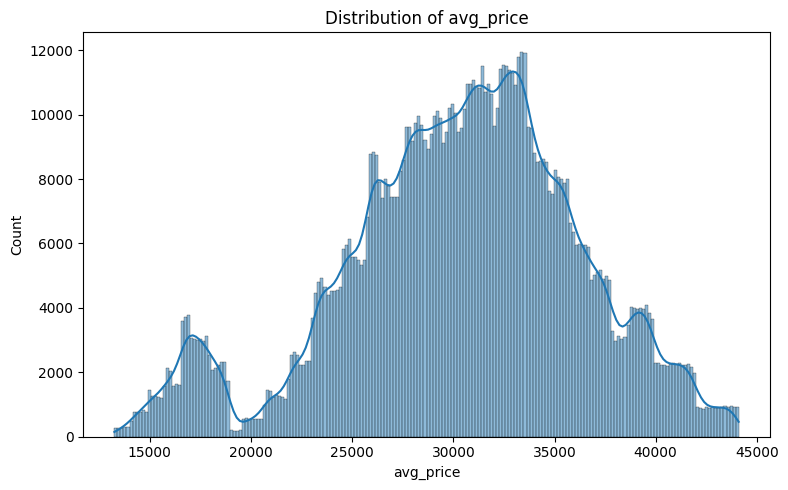

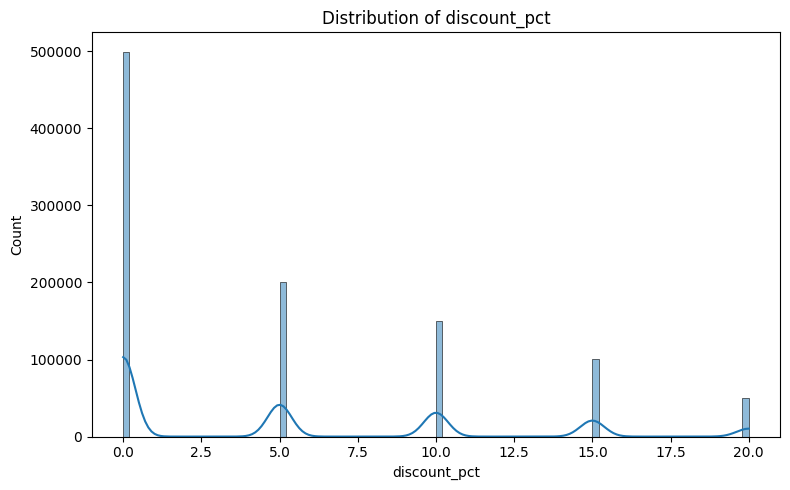

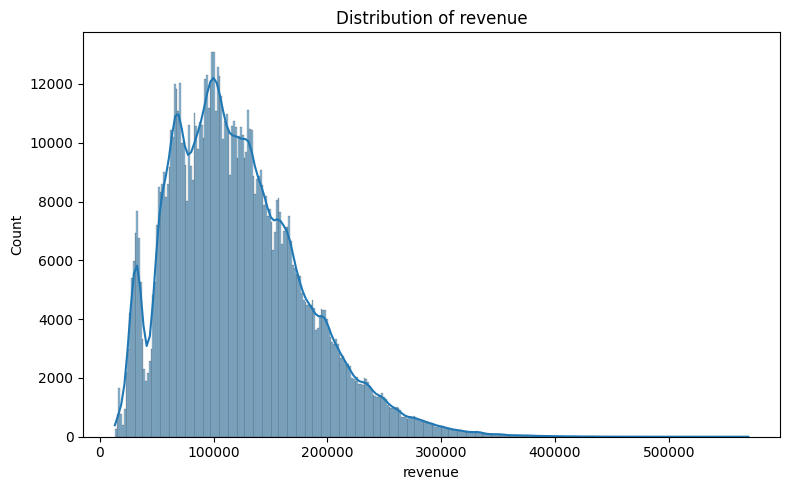

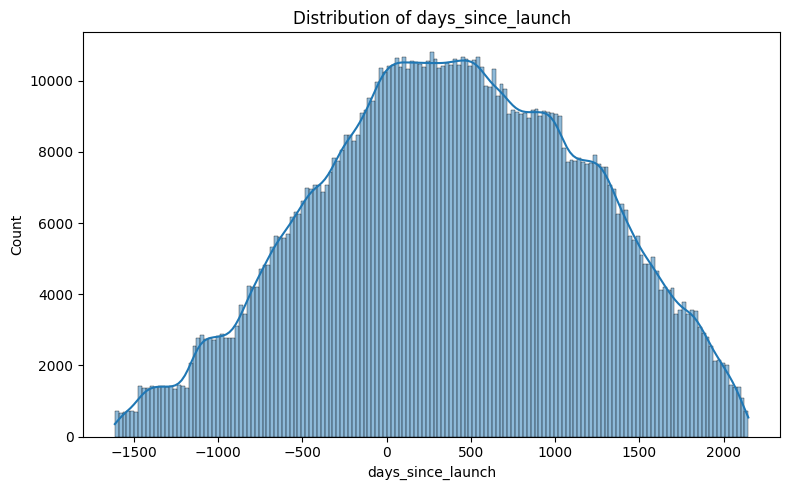

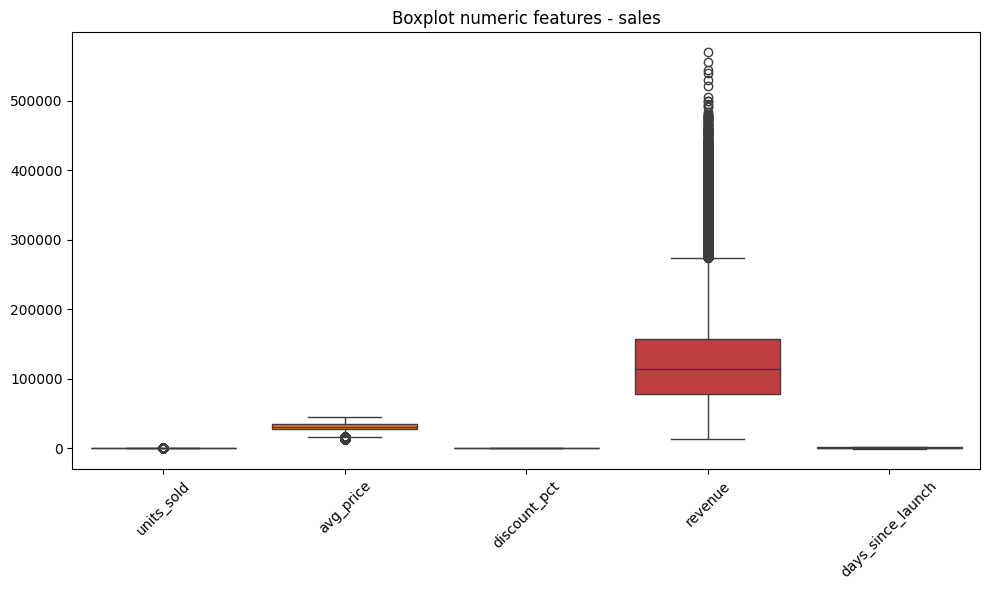

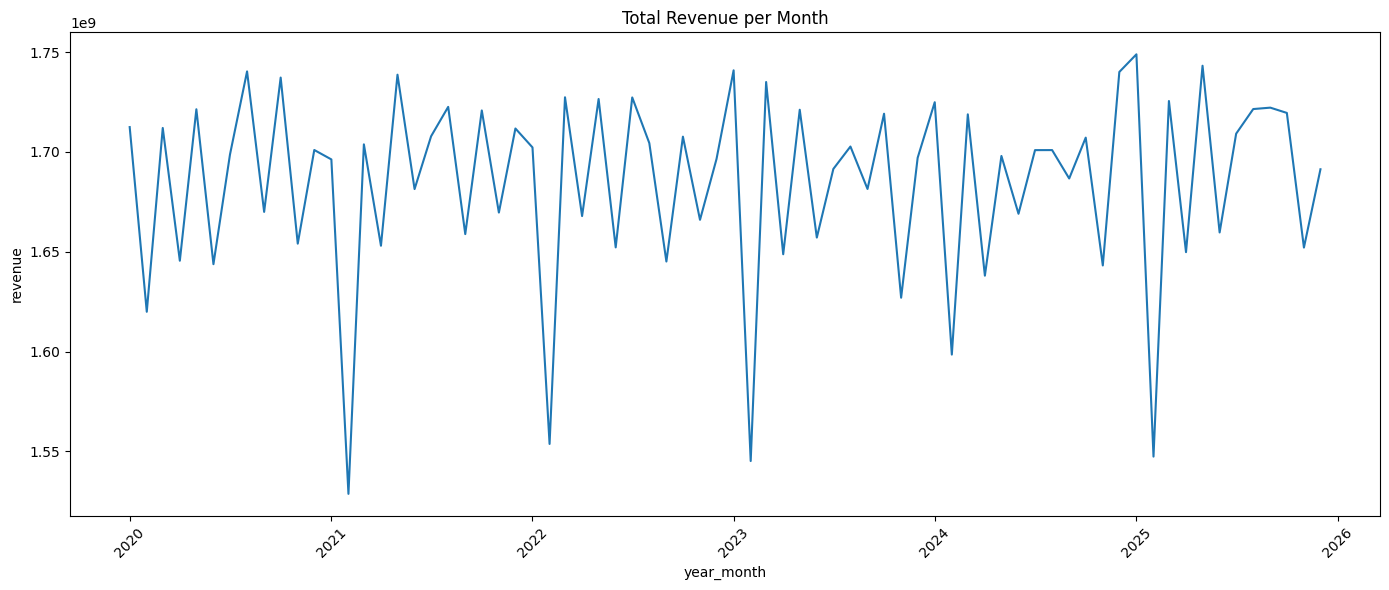

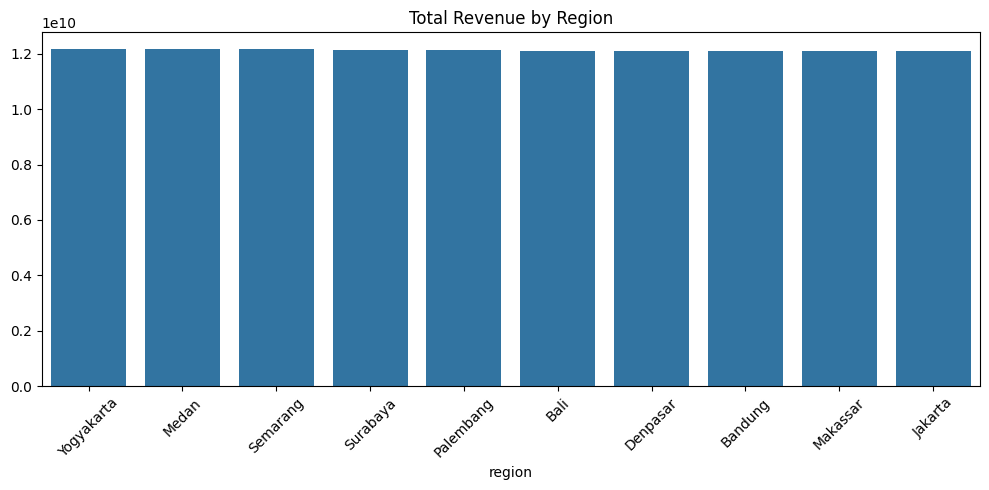

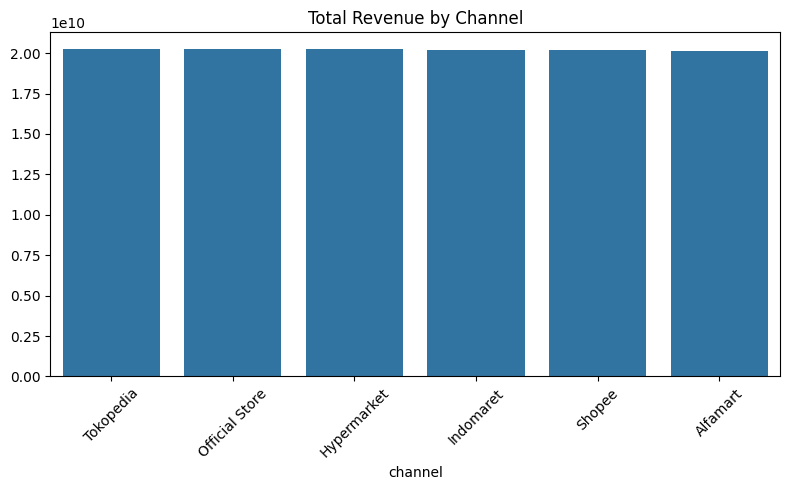

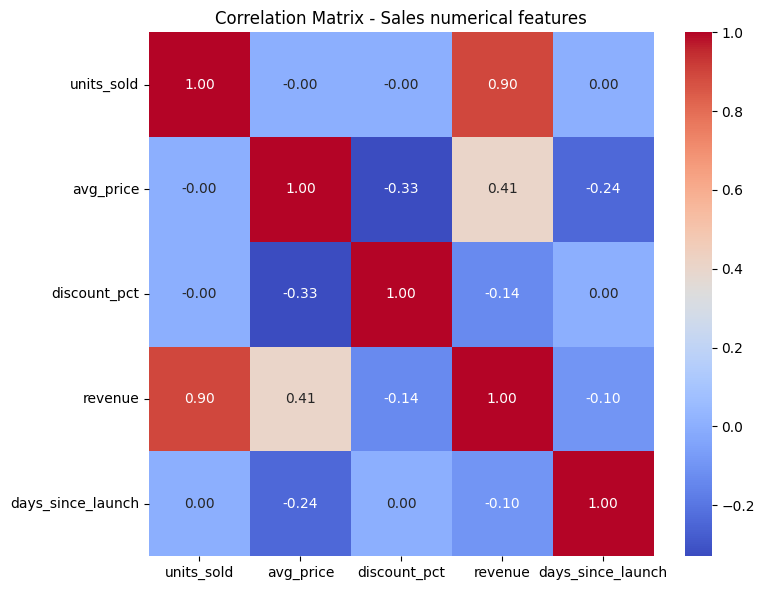

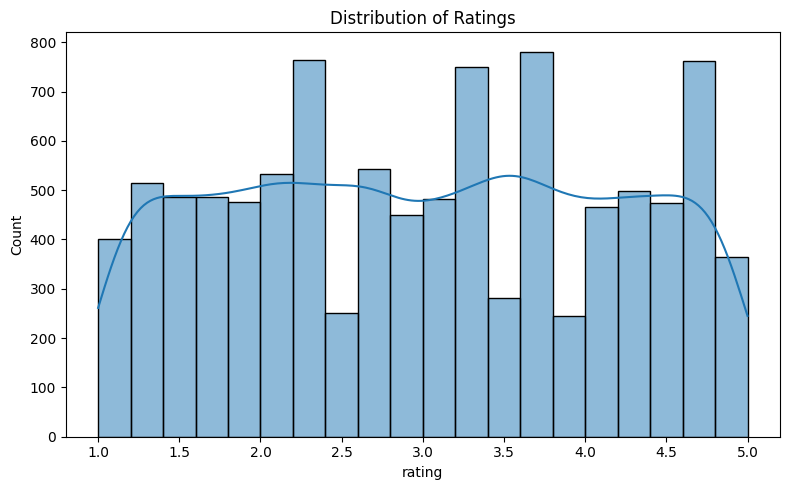

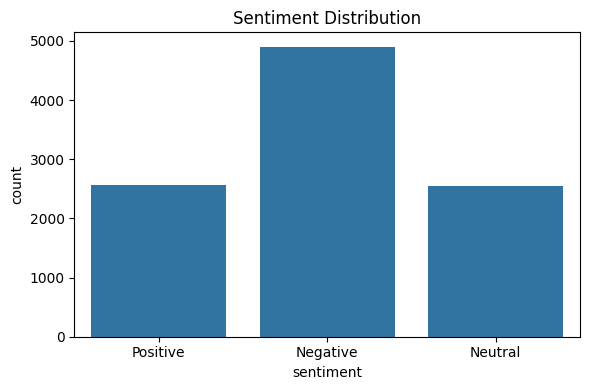

In [5]:
# ============================================================
# 3. UNIVARIATE & BIVARIATE EXPLORATION (EDA VISUAL)
# ============================================================

# Distribusi numeric utama di sales
numeric_cols_sales = ["units_sold", "avg_price", "discount_pct", "revenue", "days_since_launch"]

for col in numeric_cols_sales:
    plt.figure(figsize=(8, 5))
    sns.histplot(sales[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

# Boxplot untuk cek outlier
plt.figure(figsize=(10, 6))
sns.boxplot(data=sales[numeric_cols_sales])
plt.title("Boxplot numeric features - sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Time series: total revenue per month
sales["year_month"] = sales["date"].dt.to_period("M").dt.to_timestamp()
monthly_rev = sales.groupby("year_month")["revenue"].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_rev, x="year_month", y="revenue")
plt.title("Total Revenue per Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revenue by region & channel
plt.figure(figsize=(10, 5))
region_rev = sales.groupby("region")["revenue"].sum().sort_values(ascending=False)
sns.barplot(x=region_rev.index, y=region_rev.values)
plt.title("Total Revenue by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
channel_rev = sales.groupby("channel")["revenue"].sum().sort_values(ascending=False)
sns.barplot(x=channel_rev.index, y=channel_rev.values)
plt.title("Total Revenue by Channel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Korelasi numerik di sales
plt.figure(figsize=(8, 6))
corr = sales[numeric_cols_sales].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Sales numerical features")
plt.tight_layout()
plt.show()

# Distribusi rating & sentiment di reviews
plt.figure(figsize=(8, 5))
sns.histplot(reviews["rating"], kde=True, bins=20)
plt.title("Distribution of Ratings")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=reviews, x="sentiment")
plt.title("Sentiment Distribution")
plt.tight_layout()
plt.show()


In [6]:
# ============================================================
# FEATURE ENGINEERING (BUILD DAILY_PROD)
# ============================================================

daily_prod = (
    sales.groupby(["date","product_id"], as_index=False)
    .agg(
        total_units_sold=("units_sold","sum"),
        total_revenue=("revenue","sum"),
        avg_price=("avg_price","mean"),
        avg_discount=("discount_pct","mean"),
        avg_days_since_launch=("days_since_launch","mean"),
        n_regions=("region","nunique"),
        n_channels=("channel","nunique"),
    )
)

daily_prod = daily_prod.merge(products, on="product_id", how="left")

daily_prod["year"] = daily_prod["date"].dt.year
daily_prod["month"] = daily_prod["date"].dt.month
daily_prod["dow"] = daily_prod["date"].dt.dayofweek
daily_prod["is_weekend"] = daily_prod["dow"].isin([5,6]).astype(int)

In [7]:
# ============================================================
# FEATURE ENGINEERING MARKETING
# ============================================================

rows = []
for _, r in marketing.iterrows():
    for d in pd.date_range(r.start_date, r.end_date):
        rows.append({
            "product_id": r.product_id,
            "date": d,
            "spend": r.spend_idr,
            "engagement": r.engagement_rate,
            "channel": r.channel
        })

marketing_daily = pd.DataFrame(rows)

mkt_agg = (
    marketing_daily.groupby(["date","product_id"], as_index=False)
    .agg(
        total_spend=("spend","sum"),
        mean_engagement=("engagement","mean"),
        n_channels_mkt=("channel","nunique")
    )
)

daily_prod = daily_prod.merge(mkt_agg, on=["date","product_id"], how="left")
daily_prod.fillna(0, inplace=True)


In [14]:
# ============================================================
# FEATURE ENGINEERING SENTIMENT
# ============================================================
"""
sentiment_map = {"Negative": -1, "Neutral": 0, "Positive": 1}
reviews["sentiment_score"] = reviews["sentiment"].map(sentiment_map)

rev_agg = (
    reviews
    .groupby(["date", "product_id"], as_index=False)
    .agg(
        avg_rating=("rating", "mean"),
        sentiment_mean=("sentiment_score", "mean"),
        n_reviews=("review_id", "count")
    )
)

daily_prod = daily_prod.merge(
    rev_agg,
    on=["date", "product_id"],
    how="left"
)

daily_prod.fillna(0, inplace=True)
"""

In [8]:
missing_summary(daily_prod, "daily_prod (final)")

print("\n=== Sample of final modeling dataset ===")
print(daily_prod.head())


=== MISSING VALUE SUMMARY: daily_prod (final) ===
date                     0
product_id               0
total_units_sold         0
total_revenue            0
avg_price                0
avg_discount             0
avg_days_since_launch    0
n_regions                0
n_channels               0
product_name             0
brand                    0
type                     0
size_ml                  0
base_price               0
launch_date              0
year                     0
month                    0
dow                      0
is_weekend               0
total_spend              0
mean_engagement          0
n_channels_mkt           0
dtype: int64

=== Sample of final modeling dataset ===
        date product_id  total_units_sold  total_revenue     avg_price  \
0 2020-01-01      PC001               148     4516896.37  30361.149737   
1 2020-01-01      PC002               124     3843470.73  31003.883871   
2 2020-01-01      PC003               131     3411176.04  26354.690625   
3 20

In [10]:
reviews[["sentiment", "sentiment_encoded", "sentiment_pred"]].head()


,sentiment,sentiment_encoded,sentiment_pred
0,Positive,1,Negative
1,Negative,-1,Negative
2,Neutral,0,Negative
3,Negative,-1,Negative
4,Negative,-1,Negative


In [11]:
# ============================================================
# NLP BLOCK — FINAL VERSION (TFIDF + LSA + LDA + BERT + SENTIMENT)
# ============================================================

stop_words = set(stopwords.words("english"))

# ---------------------------------------
# 1. CLEANING FUNCTION
# ---------------------------------------
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+", "", t)
    t = re.sub(r"\d+", "", t)
    t = t.translate(str.maketrans("", "", string.punctuation))
    t = " ".join([w for w in t.split() if w not in stop_words])
    return t

# gunakan kolom 'comment'
reviews["clean"] = reviews["comment"].apply(clean_text)


# ---------------------------------------
# 2. TF-IDF REPRESENTATION
# ---------------------------------------
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(reviews["clean"])

tfidf_dense = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)
tfidf_dense["review_id"] = reviews["review_id"]


# ---------------------------------------
# 3. SENTIMENT ENCODING (label bawaan dataset)
# ---------------------------------------
sentiment_map = {"Negative": -1, "Neutral": 0, "Positive": 1}
reviews["sentiment_encoded"] = reviews["sentiment"].map(sentiment_map)


# ---------------------------------------
# 4. TRAIN CUSTOM SENTIMENT CLASSIFIER
# ---------------------------------------
X_sent = tfidf_matrix
y_sent = reviews["sentiment_encoded"]

# bisa pakai LogisticRegression
sent_clf = LogisticRegression(max_iter=2000)
sent_clf.fit(X_sent, y_sent)

reviews["sentiment_pred"] = sent_clf.predict(X_sent)
reviews["sentiment_pred_score"] = sent_clf.predict_proba(X_sent).max(axis=1)


# ---------------------------------------
# 5. TOPIC MODELING — LSA
# ---------------------------------------
lsa = TruncatedSVD(n_components=20)
lsa_features = lsa.fit_transform(tfidf_matrix)

lsa_df = pd.DataFrame(
    lsa_features,
    columns=[f"lsa_{i}" for i in range(20)]
)
lsa_df["review_id"] = reviews["review_id"]


# ---------------------------------------
# 6. TOPIC MODELING — LDA
# ---------------------------------------
lda = LatentDirichletAllocation(n_components=8)
lda_features = lda.fit_transform(tfidf_matrix)

lda_df = pd.DataFrame(
    lda_features,
    columns=[f"topic_{i}" for i in range(8)]
)
lda_df["review_id"] = reviews["review_id"]


# ---------------------------------------
# 7. BERT EMBEDDINGS
# ---------------------------------------
bert = SentenceTransformer("all-MiniLM-L6-v2")
bert_embeddings = bert.encode(reviews["clean"], show_progress_bar=True)

bert_df = pd.DataFrame(
    bert_embeddings,
    columns=[f"bert_{i}" for i in range(384)]
)
bert_df["review_id"] = reviews["review_id"]


# ---------------------------------------
# 8. MERGE SEMUA NLP FEATURE LEVEL REVIEW
# ---------------------------------------
nlp_full = (
    reviews[[
        "review_id",
        "product_id",
        "date",
        "rating",
        "sentiment_encoded",
        "sentiment_pred",
        "sentiment_pred_score"
    ]]
    .merge(lsa_df, on="review_id")
    .merge(lda_df, on="review_id")
    .merge(bert_df, on="review_id")
)


# ---------------------------------------
# 9. AGGREGATE NLP FEATURES PER PRODUCT PER DAY
# ---------------------------------------
nlp_daily = (
    nlp_full.groupby(["product_id","date"])
    .agg({
        "rating": "mean",
        "sentiment_encoded": "mean",      # sentiment asli
        "sentiment_pred": "mean",         # sentiment model
        "sentiment_pred_score": "mean",   # confidence model
        **{col: "mean" for col in lsa_df.columns if col != "review_id"},
        **{col: "mean" for col in lda_df.columns if col != "review_id"},
        **{col: "mean" for col in bert_df.columns if col != "review_id"},
    })
    .reset_index()
)


# ---------------------------------------
# 10. MERGE NLP → daily_prod
# ---------------------------------------
daily_merged = daily_prod.merge(nlp_daily, on=["product_id","date"], how="left")
daily_merged.fillna(0, inplace=True)

print("NLP block completed. daily_merged shape:", daily_merged.shape)


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

NLP block completed. daily_merged shape: (32880, 438)


In [12]:
# ============================================================
# MODELLING (REGRESI)
# ============================================================

train = daily_merged[daily_merged.date < "2024-01-01"]
test  = daily_merged[daily_merged.date >= "2024-01-01"]

y_train = train["total_revenue"]
y_test = test["total_revenue"]

num_cols = ["total_units_sold","avg_price","avg_discount","avg_days_since_launch","total_spend"]
cat_cols = ["product_id","brand","type"]
nlp_cols = [c for c in daily_merged.columns if c.startswith(("lsa","topic","bert"))]

X_train = train[num_cols + cat_cols + nlp_cols]
X_test  = test[num_cols + cat_cols + nlp_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("nlp", "passthrough", nlp_cols),
    ]
)


In [13]:
# Baseline : Random Forest
rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))

RMSE: 27848.543116228408
R²: 0.9992211845832847


In [ ]:
# ============================================================
# HYPERPARAMETER TUNING (OPTUNA)
# ============================================================

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 200, 800)
    max_depth = trial.suggest_int("max_depth", 5, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 15)

    model = Pipeline([
        ("prep", preprocess),
        ("rf", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, pred))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("BEST PARAMS:", study.best_params)


In [ ]:
# ============================================================
# ENSEMBLING (STACKING + VOTING)
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

stack_model = StackingRegressor(
    estimators=[
        ("lr", LinearRegression()),
        ("rf", RandomForestRegressor(n_estimators=300)),
        ("gb", GradientBoostingRegressor())
    ],
    final_estimator=Ridge(alpha=1.0)
)

final_pipe = Pipeline([
    ("prep", preprocess),
    ("stack", stack_model)
])

final_pipe.fit(X_train, y_train)
pred_stack = final_pipe.predict(X_test)

print("STACK RMSE:", np.sqrt(mean_squared_error(y_test, pred_stack)))


In [ ]:
# ============================================================
# FORECASTING
# ============================================================
# Pilih product_id untuk forecasting
TARGET_PRODUCT = "PC001"

ts = (
    daily_merged[daily_merged["product_id"] == TARGET_PRODUCT]
    .sort_values("date")
    [["date", "total_revenue"]]
    .rename(columns={"date": "ds", "total_revenue": "y"})
)
ts = ts.set_index("ds")
ts.head()

In [ ]:
# Prophet Model

!pip install prophet --quiet
from prophet import Prophet

# Prophet butuh index normal
ts_prophet = ts.reset_index()

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.3
)

model_prophet.fit(ts_prophet)

# Forecast 90 hari ke depan
future = model_prophet.make_future_dataframe(periods=90)
forecast_prophet = model_prophet.predict(future)

forecast_prophet.tail()

model_prophet.plot(forecast_prophet)
plt.title(f"Prophet Forecast — {TARGET_PRODUCT}")
plt.show()

In [ ]:
# ARIMA Auto

!pip install pmdarima --quiet
from pmdarima import auto_arima

train_arima = ts.iloc[:-60]
test_arima  = ts.iloc[-60:]

arima_model = auto_arima(
    train_arima,
    seasonal=False,
    trace=False,
    suppress_warnings=True
)

arima_pred = arima_model.predict(n_periods=60)

rmse_arima = np.sqrt(mean_squared_error(test_arima, arima_pred))
rmse_arima

In [ ]:
# XGBoost Time-Series

df_ml = ts.copy()
df_ml["lag_1"] = df_ml["y"].shift(1)
df_ml["lag_7"] = df_ml["y"].shift(7)
df_ml["lag_30"] = df_ml["y"].shift(30)
df_ml = df_ml.dropna()

train_ml = df_ml.iloc[:-60]
test_ml = df_ml.iloc[-60:]

X_train = train_ml.drop("y", axis=1)
y_train = train_ml["y"]

X_test  = test_ml.drop("y", axis=1)
y_test  = test_ml["y"]

from xgboost import XGBRegressor

xgb_ts = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_ts.fit(X_train, y_train)
xgb_pred = xgb_ts.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
rmse_xgb

In [ ]:
# ENSEMBLE Forecasting

# Samakan panjang prediksi 60 hari
ens_pred = (arima_pred + xgb_pred) / 2

rmse_ens = np.sqrt(mean_squared_error(y_test, ens_pred))
rmse_ens

In [ ]:
# XGBoost 90-day Forecast Loop

future_preds = []

last_row = df_ml.iloc[-1:].copy()

for i in range(90):
    xr = last_row.drop("y", axis=1)
    pred = xgb_ts.predict(xr)[0]

    future_preds.append(pred)

    # update lag features
    new_row = pd.DataFrame({"y": pred}, index=[ts.index.max() + pd.Timedelta(days=i+1)])
    new_row["lag_1"] = pred
    new_row["lag_7"] = df_ml["y"].iloc[-7+i] if i < 7 else future_preds[-7]
    new_row["lag_30"] = df_ml["y"].iloc[-30+i] if i < 30 else future_preds[-30]

    last_row = new_row.copy()


In [ ]:
# ============================================================
# CANNIBALIZATION ANALYSIS
# ============================================================
prod_pivot = (
    daily_merged.pivot(index="date", columns="product_id", values="total_revenue")
    .fillna(0)
)

corr_matrix = prod_pivot.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Product Cannibalization Matrix (Correlation)")
plt.show()


In [ ]:
# ============================================================
# INNOVATION RADAR
# ============================================================

growth = (
    daily_merged.groupby("product_id")["total_revenue"]
    .apply(lambda x: (x.tail(30).mean() - x.head(30).mean()) / (x.head(30).mean()+1))
)

innov_radar = pd.DataFrame({
    "product_id": growth.index,
    "growth_score": growth.values
}).sort_values("growth_score", ascending=False)

innov_radar
